# BÀI TẬP 3.2 Nhận dạng chữ viết tay

---

**Họ và tên:** Nguyễn Quang Linh
**MSSV:** 038205003016

---

# Import Thư Viện
Khai báo các thư viện cần thiết cho việc xử lý dữ liệu, NLP, training mô hình và vẽ biểu đồ.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

# NLP Vectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD # Dùng để giảm chiều vẽ hình

# Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Bước 1. Load data từ file dataset
Đọc dữ liệu từ file `SMSSpamCollection`. File này phân cách bằng tab (`\t`) và chưa có header.

In [3]:
# Load dữ liệu (Cần đảm bảo file SMSSpamCollection nằm cùng thư mục hoặc dùng link online)
try:
    df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'], encoding='latin-1')
except:

    df = pd.read_csv("../../data/Elearning03/smsspamcollection/SMSSpamCollection", sep='\t', names=['label', 'message'], header=None, encoding='latin-1')

print(f"Kích thước dữ liệu: {df.shape}")
df.head()

Kích thước dữ liệu: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Bước 2. Preprocessing Data (Bỏ noise)
- Xóa dấu câu và chuyển về chữ thường.
- Chuyển đổi nhãn (Label Encoding): `ham` -> 0, `spam` -> 1.

In [4]:
# Hàm làm sạch text
def clean_text(text):
    nopunc = [char for char in text if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    return nopunc.lower()

# Áp dụng làm sạch
df['clean_msg'] = df['message'].apply(clean_text)

# Chuyển nhãn thành số
df['label_num'] = df.label.map({'ham': 0, 'spam': 1})
y = df['label_num']

df[['message', 'clean_msg', 'label_num']].head()

,message,clean_msg,label_num
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,0


# Bước 3. Vector hóa dữ liệu (Feature Extraction)
Thực hiện 2 phương án vector hóa như yêu cầu:
1. **CountVectorizer**: Đếm tần suất từ.
2. **TfidfVectorizer**: Tính trọng số quan trọng của từ.

*Lưu ý: Chúng ta sẽ sử dụng kết quả của **TF-IDF** để đưa vào huấn luyện ở bước sau vì nó thường hiệu quả hơn.*

In [5]:
# 1. Phương án CountVectorizer
cv = CountVectorizer(stop_words='english')
X_count = cv.fit_transform(df['clean_msg'])
print(f"Shape CountVectorizer: {X_count.shape}")

# 2. Phương án TfidfVectorizer (Sẽ dùng cái này để Train)
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(df['clean_msg'])
print(f"Shape TfidfVectorizer: {X_tfidf.shape}")

Shape CountVectorizer: (5572, 9311)
Shape TfidfVectorizer: (5572, 9311)


# Bước 4. Train với 2 mô hình SVM và KNN
- Chia dữ liệu: 80% Train - 20% Test.
- Khởi tạo và huấn luyện 2 mô hình:
    - **SVM**: Support Vector Machine (Kernel Sigmoid).
    - **KNN**: K-Nearest Neighbors (K=5).

In [6]:
# Split dữ liệu (Dùng X_tfidf)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# --- Mô hình 1: SVM ---
print("Đang train SVM...")
svm = SVC(kernel='sigmoid', gamma=1.0)
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

# --- Mô hình 2: KNN ---
print("Đang train KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print("Hoàn tất huấn luyện!")

Đang train SVM...
Đang train KNN...
Hoàn tất huấn luyện!


# Bước 5. So sánh kết quả và Plot
- In báo cáo độ chính xác (Accuracy, Precision, Recall).
- Vẽ biểu đồ phân tán (Scatter Plot) sau khi giảm chiều dữ liệu xuống 2D bằng SVD để trực quan hóa vùng phân loại.

--- KẾT QUẢ SVM ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115

------------------------------
--- KẾT QUẢ KNN ---
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       966
           1       1.00      0.32      0.48       149

    accuracy                           0.91      1115
   macro avg       0.95      0.66      0.71      1115
weighted avg       0.92      0.91      0.89      1115



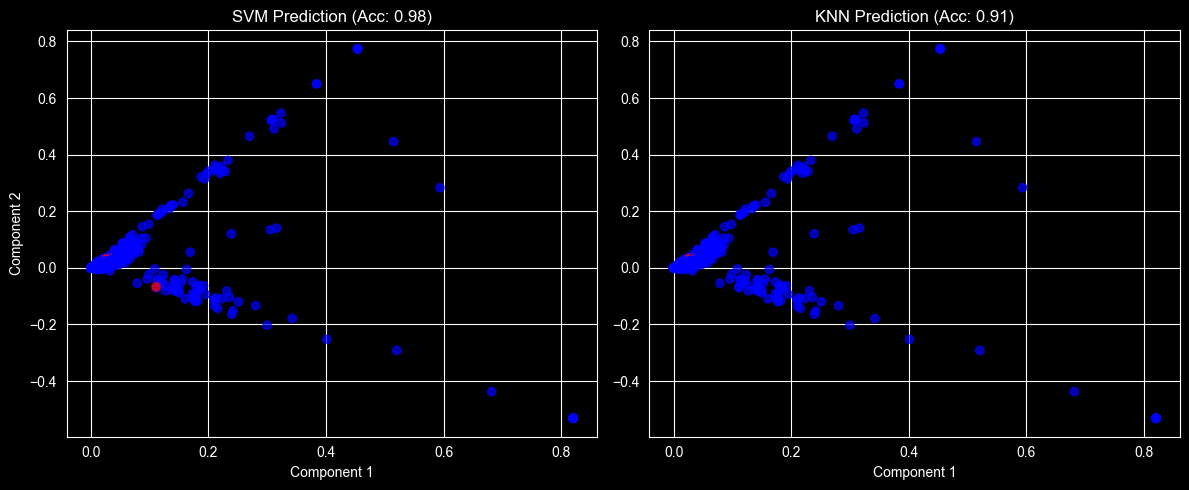

In [7]:
# 1. So sánh chỉ số
print("--- KẾT QUẢ SVM ---")
print(classification_report(y_test, pred_svm))
print("-" * 30)
print("--- KẾT QUẢ KNN ---")
print(classification_report(y_test, pred_knn))

# 2. Vẽ biểu đồ (Visualization)
# Dùng TruncatedSVD để giảm xuống 2 chiều (2D) để vẽ
svd = TruncatedSVD(n_components=2, random_state=42)
X_test_2d = svd.fit_transform(X_test)

plt.figure(figsize=(12, 5))

# Plot SVM
plt.subplot(1, 2, 1)
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=pred_svm, cmap='bwr', alpha=0.7)
plt.title(f'SVM Prediction (Acc: {accuracy_score(y_test, pred_svm):.2f})')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

# Plot KNN
plt.subplot(1, 2, 2)
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=pred_knn, cmap='bwr', alpha=0.7)
plt.title(f'KNN Prediction (Acc: {accuracy_score(y_test, pred_knn):.2f})')
plt.xlabel('Component 1')

plt.tight_layout()
plt.show()